In [2]:
import os
import shutil
import random

DATASET_DIR = "UCF11_updated_mpg"
OUTPUT_DIR = "UCF11_split"
SPLIT = [0.7, 0.15, 0.15]

os.makedirs(OUTPUT_DIR, exist_ok=True)

def collect_videos(class_path):
    files = []
    for root,_,fps in os.walk(class_path):
        for f in fps:
            if f.endswith(".mpg"):
                files.append(os.path.join(root,f))
    return files

classes = os.listdir(DATASET_DIR)

for cls in classes:
    class_path = os.path.join(DATASET_DIR, cls)
    videos = collect_videos(class_path)
    random.shuffle(videos)

    train_end = int(len(videos) * SPLIT[0])
    val_end = train_end + int(len(videos) * SPLIT[1])

    subsets = {
        "train": videos[:train_end],
        "val": videos[train_end:val_end],
        "test": videos[val_end:]
    }

    for subset, paths in subsets.items():
        out_dir = os.path.join(OUTPUT_DIR, subset, cls)
        os.makedirs(out_dir, exist_ok=True)

        for video_path in paths:
            fname = os.path.basename(video_path)
            shutil.copy(video_path, os.path.join(out_dir, fname))

print("Dataset splitting done!")


Dataset splitting done!


In [5]:
!pip install opencv-python
import os
import cv2
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
import random

class VideoDataset(Dataset):
    def __init__(self, root_dir, frames_per_clip=16):
        self.root_dir = root_dir
        self.frames_per_clip = frames_per_clip
        
        self.samples = []
        self.classes = sorted(os.listdir(root_dir))
        
        for cls in self.classes:
            folder = os.path.join(root_dir, cls)
            for f in os.listdir(folder):
                self.samples.append((os.path.join(folder, f), cls))
        
        self.class2idx = {c:i for i,c in enumerate(self.classes)}

        self.transform = T.Compose([
            T.ToTensor(),
            T.Resize((112,112)),
        ])

    def __len__(self):
        return len(self.samples)

    def load_frames(self, path):
        cap = cv2.VideoCapture(path)
        frames = []

        while True:
            ok, frame = cap.read()
            if not ok:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)
        
        cap.release()
        return frames

    def sample_frames(self, frames):
        if len(frames) >= self.frames_per_clip:
            start = random.randint(0, len(frames)-self.frames_per_clip)
            return frames[start:start+self.frames_per_clip]

        while len(frames) < self.frames_per_clip:
            frames.append(frames[-1])
        return frames

    def __getitem__(self, idx):
        path, cls = self.samples[idx]
        frames = self.load_frames(path)
        frames = self.sample_frames(frames)

        frames = [self.transform(frame) for frame in frames]
        video_tensor = torch.stack(frames)  # (T, C, H, W)

        return video_tensor, self.class2idx[cls]


  Using cached numpy-2.2.6-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.9/37.9 MB 2.0 MB/s  0:00:18m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 1.7 MB/s  0:00:03 eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.4
    Uninstalling numpy-2.3.4:
      Successfully uninstalled numpy-2.3.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [opencv-python]0m [opencv-python]


In [13]:
from torch.utils.data import DataLoader

train_ds = VideoDataset("UCF11_split/train")
val_ds   = VideoDataset("UCF11_split/val")
test_ds  = VideoDataset("UCF11_split/test")

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=4)
test_loader  = DataLoader(test_ds, batch_size=4)


In [14]:
import torch
import torch.nn as nn
from torchvision.models import resnet18

class CNNLSTM(nn.Module):
    def __init__(self, num_classes=11, hidden_size=256):
        super().__init__()

        base = resnet18(weights='IMAGENET1K_V1')
        base.fc = nn.Identity()
        self.cnn = base

        self.lstm = nn.LSTM(
            input_size=512,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        B, T, C, H, W = x.size()
        
        x = x.view(B*T, C, H, W)
        feats = self.cnn(x)
        feats = feats.view(B, T, 512)

        _, (h, _) = self.lstm(feats)
        out = self.fc(h[-1])
        return out


In [15]:
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt

device = "mps" if torch.mps.is_available() else "cpu"
print("Using:", device)

model = CNNLSTM().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 10

train_acc_list = []
val_acc_list   = []
train_loss_list = []
val_loss_list   = []
epoch_times = []

total_start = time.time()

best_val_loss = float("inf")
patience = 3
patience_counter = 0

for epoch in range(num_epochs):
    epoch_start = time.time()
    
    # ========== TRAIN ==========
    model.train()
    running_loss = 0
    total, correct = 0, 0

    for X, y in train_loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(out, 1)
        total += y.size(0)
        correct += (preds == y).sum().item()

    train_acc = correct / total
    train_loss = running_loss / len(train_loader)


    # ========== VAL ==========
    model.eval()
    total, correct = 0, 0
    running_loss = 0

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)

            running_loss += loss.item()
            _, preds = torch.max(out, 1)
            total += y.size(0)
            correct += (preds == y).sum().item()

    val_acc = correct / total
    val_loss = running_loss / len(val_loader)

    epoch_time = time.time() - epoch_start

    # save metrics
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    epoch_times.append(epoch_time)

    # PRINT EVERYTHING WE WANT
    print(
        f"Epoch {epoch+1}/{num_epochs}  "
        f"Train Loss: {train_loss:.3f}  Train Acc: {train_acc:.3f} | "
        f"Val Loss: {val_loss:.3f}  Val Acc: {val_acc:.3f} | "
        f"Time: {epoch_time:.2f}s"
    )

    # ========== CHECKPOINT ==========
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save(model.state_dict(), "best_model.pth")
        print("   ✓ Saved new best model")
    else:
        patience_counter += 1
        print(f"   ✗ No improvement ({patience_counter}/{patience})")

        if patience_counter >= patience:
            print("\nEARLY STOPPING triggered!")
            break

print(f"\nTotal training time: {time.time() - total_start:.2f}s")


Using: mps
Epoch 1/10  Train Loss: 1.635  Train Acc: 0.516 | Val Loss: 0.758  Val Acc: 0.800 | Time: 143.19s
   ✓ Saved new best model
Epoch 2/10  Train Loss: 0.834  Train Acc: 0.776 | Val Loss: 0.529  Val Acc: 0.860 | Time: 146.45s
   ✓ Saved new best model
Epoch 3/10  Train Loss: 0.592  Train Acc: 0.835 | Val Loss: 0.350  Val Acc: 0.915 | Time: 146.29s
   ✓ Saved new best model
Epoch 4/10  Train Loss: 0.470  Train Acc: 0.875 | Val Loss: 0.401  Val Acc: 0.898 | Time: 146.78s
   ✗ No improvement (1/3)
Epoch 5/10  Train Loss: 0.386  Train Acc: 0.892 | Val Loss: 0.303  Val Acc: 0.928 | Time: 146.33s
   ✓ Saved new best model
Epoch 6/10  Train Loss: 0.417  Train Acc: 0.888 | Val Loss: 0.318  Val Acc: 0.919 | Time: 146.43s
   ✗ No improvement (1/3)
Epoch 7/10  Train Loss: 0.331  Train Acc: 0.909 | Val Loss: 0.317  Val Acc: 0.906 | Time: 146.30s
   ✗ No improvement (2/3)
Epoch 8/10  Train Loss: 0.311  Train Acc: 0.920 | Val Loss: 0.388  Val Acc: 0.894 | Time: 146.48s
   ✗ No improvement (3/

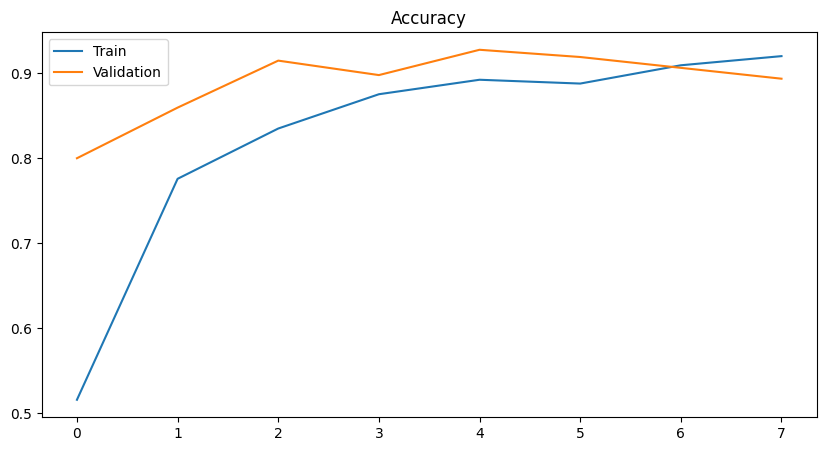

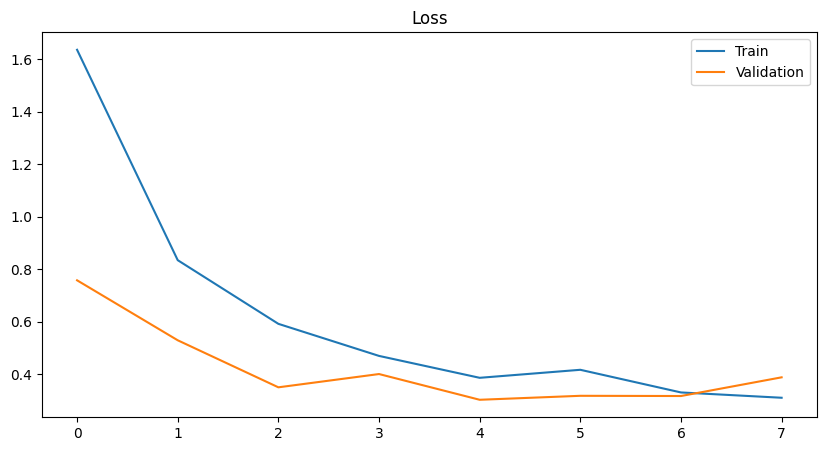

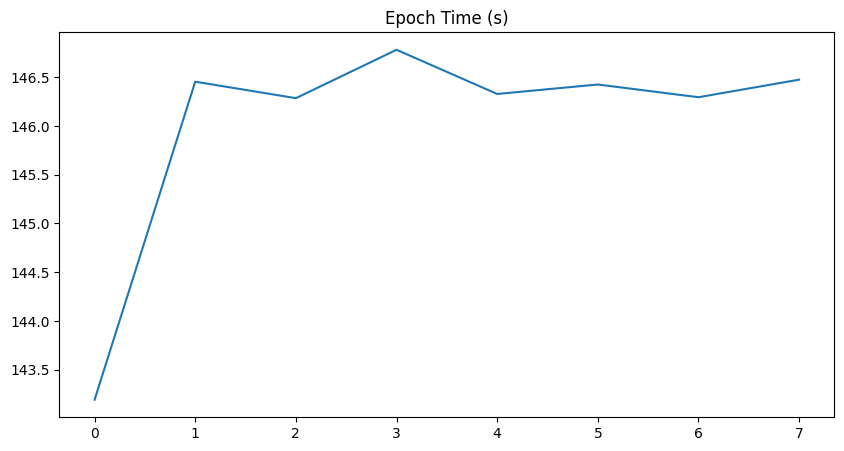

In [16]:
# ========== PLOTTING ==========

plt.figure(figsize=(10,5))
plt.plot(train_acc_list)
plt.plot(val_acc_list)
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.figure(figsize=(10,5))
plt.plot(train_loss_list)
plt.plot(val_loss_list)
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()

plt.figure(figsize=(10,5))
plt.plot(epoch_times)
plt.title("Epoch Time (s)")
plt.show()


In [ ]:
# === TEST ACCURACY ONLY ===
model = CNNLSTM().to(device)
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        _, preds = torch.max(outputs, 1)
        test_total += y.    size(0)
        test_correct += (preds == y).sum().item()

test_acc = test_correct / test_total
print(f"\nTest Accuracy: {test_acc:.3f}")



Test Accuracy: 0.928


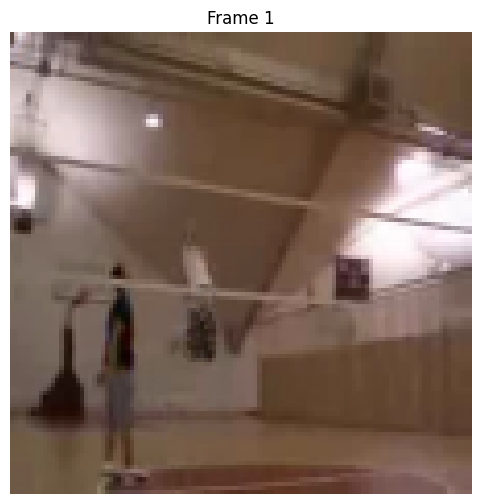

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.003216362..1.0000001].


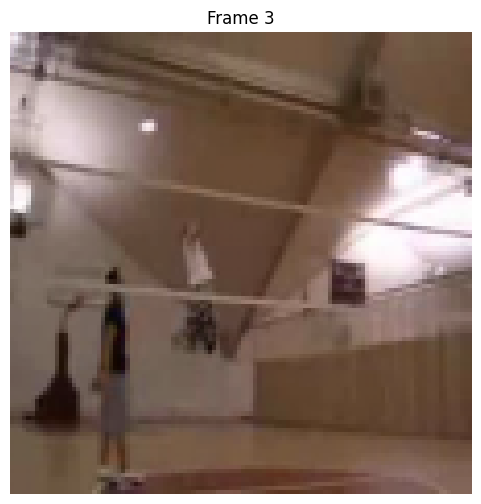

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0009694469..1.0000001].


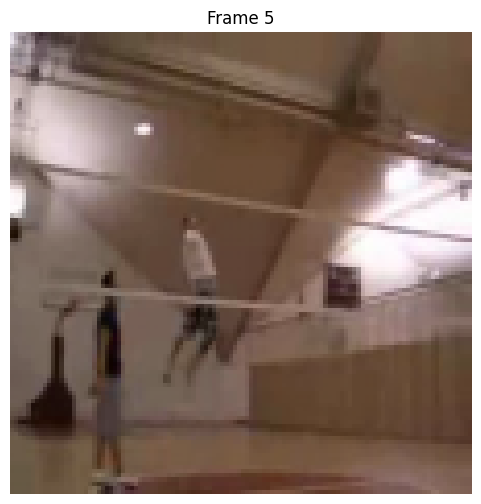

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.011258444..1.0000002].


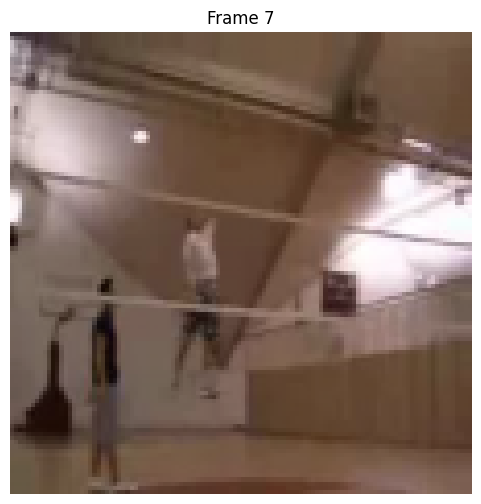

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0058898553..1.0000002].


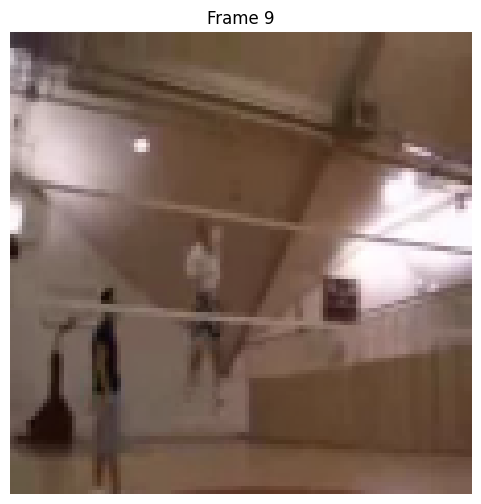

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0022284775..1.0000002].


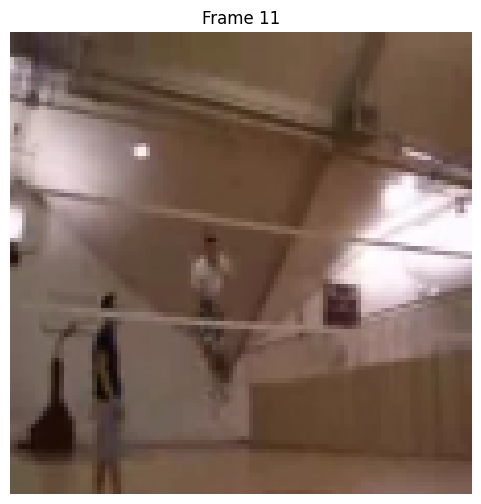

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.00853646..1.0000001].


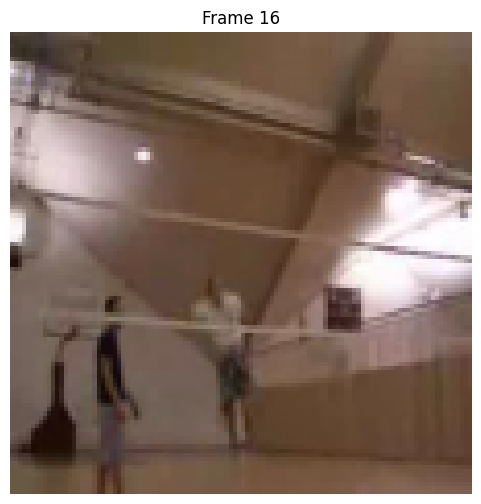

True label:    volleyball_spiking
Predicted as:  volleyball_spiking


In [36]:
import matplotlib.pyplot as plt
import random

class_names = test_loader.dataset.classes
frames_per_clip = test_loader.dataset.frames_per_clip

# 7 frameova
idxs = [0, 2, 4, 6, 8, 10, 15]

r = random.randint(0, len(test_loader.dataset)-1)

X, true = test_loader.dataset[r]
X_one = X.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    pred = model(X_one).argmax(1).item()

# prikaz 7 frameova
for j in idxs:
    f = X[j].permute(1,2,0).numpy()
    plt.figure(figsize=(6,6))
    plt.imshow(f)
    plt.axis("off")
    plt.title(f"Frame {j+1}")
    plt.show()

print("True label:   ", class_names[true])
print("Predicted as: ", class_names[pred])


In [37]:
class VideoDataset3D(VideoDataset):
    def __getitem__(self, idx):
        video, label = super().__getitem__(idx)  # (T, C, H, W)
        video = video.permute(1, 0, 2, 3)        # -> (C, T, H, W)
        return video, label


In [38]:
train_ds_3d = VideoDataset3D("UCF11_split/train")
val_ds_3d   = VideoDataset3D("UCF11_split/val")
test_ds_3d  = VideoDataset3D("UCF11_split/test")

train_loader_3d = DataLoader(train_ds_3d, batch_size=4, shuffle=True)
val_loader_3d   = DataLoader(val_ds_3d, batch_size=4)
test_loader_3d  = DataLoader(test_ds_3d, batch_size=4)


In [41]:
import torch.nn as nn

class C3D(nn.Module):
    def __init__(self, num_classes=11):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv3d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(2),

            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(2),

            nn.Conv3d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d((1,2,2)),

            nn.Conv3d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool3d(2),
        )

        self.classifier = nn.Sequential(
        nn.AdaptiveAvgPool3d((1, 1, 1)),   # <---- MAGIC LINE
        nn.Flatten(),
        nn.Linear(512, 4096),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(4096, num_classes)
    )


    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [42]:
import time
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

model = C3D().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 10

train_acc_list = []
val_acc_list   = []
train_loss_list = []
val_loss_list   = []
epoch_times = []

best_val_loss = float("inf")
patience = 3
patience_counter = 0

total_start = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()
    
    # ========== TRAIN ==========
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for X, y in train_loader_3d:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(out, 1)
        total += y.size(0)
        correct += (preds == y).sum().item()

    train_acc = correct / total
    train_loss = running_loss / len(train_loader_3d)


    # ========== VAL ==========
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in val_loader_3d:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)

            running_loss += loss.item()
            _, preds = torch.max(out, 1)
            total += y.size(0)
            correct += (preds == y).sum().item()

    val_acc = correct / total
    val_loss = running_loss / len(val_loader_3d)

    epoch_time = time.time() - epoch_start

    # spremi metrike
    train_acc_list.append(train_acc)
    val_acc_list.append(val_acc)
    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)
    epoch_times.append(epoch_time)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"Train Loss: {train_loss:.3f} Train Acc: {train_acc:.3f} | "
        f"Val Loss: {val_loss:.3f} Val Acc: {val_acc:.3f} | "
        f"Time: {epoch_time:.2f}s"
    )

    # ========== CHECKPOINT ==========
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model_3d.pth")
        print("   ✓ Saved new best model")
    else:
        patience_counter += 1
        print(f"   ✗ No improvement ({patience_counter}/{patience})")

        if patience_counter >= patience:
            print("\nEARLY STOPPING triggered!")
            break


print(f"\nTotal training time: {time.time() - total_start:.2f}s")


Epoch 1/10 Train Loss: 2.396 Train Acc: 0.118 | Val Loss: 2.385 Val Acc: 0.123 | Time: 431.84s
   ✓ Saved new best model
Epoch 2/10 Train Loss: 2.382 Train Acc: 0.122 | Val Loss: 2.349 Val Acc: 0.162 | Time: 431.51s
   ✓ Saved new best model
Epoch 3/10 Train Loss: 2.285 Train Acc: 0.170 | Val Loss: 2.181 Val Acc: 0.179 | Time: 432.01s
   ✓ Saved new best model
Epoch 4/10 Train Loss: 2.064 Train Acc: 0.255 | Val Loss: 1.794 Val Acc: 0.370 | Time: 449.52s
   ✓ Saved new best model
Epoch 5/10 Train Loss: 1.816 Train Acc: 0.348 | Val Loss: 1.713 Val Acc: 0.374 | Time: 496.42s
   ✓ Saved new best model
Epoch 6/10 Train Loss: 1.669 Train Acc: 0.419 | Val Loss: 1.544 Val Acc: 0.409 | Time: 540.74s
   ✓ Saved new best model
Epoch 7/10 Train Loss: 1.576 Train Acc: 0.460 | Val Loss: 1.419 Val Acc: 0.485 | Time: 485.73s
   ✓ Saved new best model
Epoch 8/10 Train Loss: 1.401 Train Acc: 0.522 | Val Loss: 1.357 Val Acc: 0.515 | Time: 470.10s
   ✓ Saved new best model
Epoch 9/10 Train Loss: 1.316 Tra

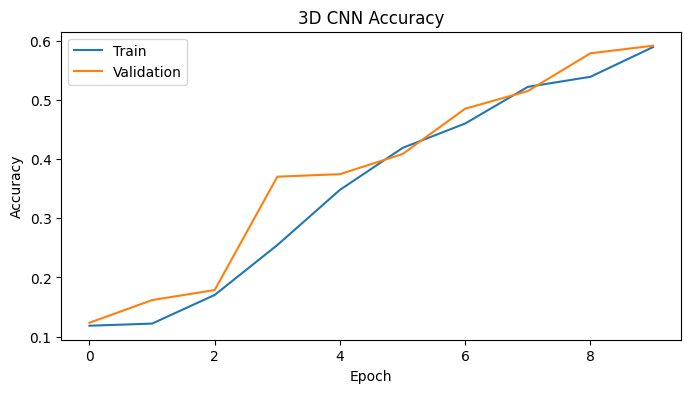

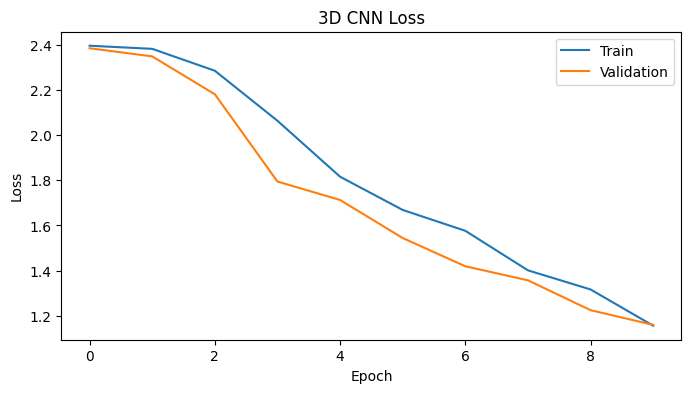

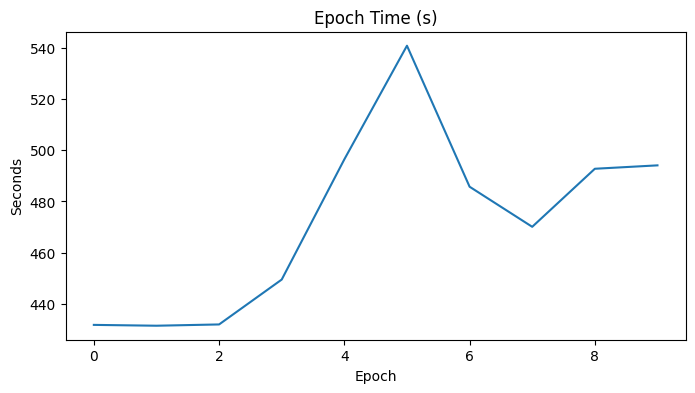

In [43]:
import matplotlib.pyplot as plt

# ACCURACY
plt.figure(figsize=(8,4))
plt.plot(train_acc_list)
plt.plot(val_acc_list)
plt.title("3D CNN Accuracy")
plt.legend(["Train", "Validation"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# LOSS
plt.figure(figsize=(8,4))
plt.plot(train_loss_list)
plt.plot(val_loss_list)
plt.title("3D CNN Loss")
plt.legend(["Train", "Validation"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# TIME
plt.figure(figsize=(8,4))
plt.plot(epoch_times)
plt.title("Epoch Time (s)")
plt.xlabel("Epoch")
plt.ylabel("Seconds")
plt.show()


In [44]:
# === TEST ACCURACY FOR 3D CNN ===

model = C3D().to(device)
model.load_state_dict(torch.load("best_model_3d.pth"))
model.eval()

test_correct = 0
test_total = 0

with torch.no_grad():
    for X, y in test_loader_3d:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        _, preds = torch.max(outputs, 1)
        test_total += y.size(0)
        test_correct += (preds == y).sum().item()

test_acc = test_correct / test_total
print(f"\n3D CNN Test Accuracy: {test_acc:.3f}")



3D CNN Test Accuracy: 0.584
